In [9]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset (1).zip


In [11]:
import os

print(os.listdir())

['.config', 'dataset (1).zip', 'dataset.zip', 'sample_data']


In [12]:
import zipfile

print("dataset.zip:", zipfile.is_zipfile("dataset.zip"))
print("dataset (1).zip:", zipfile.is_zipfile("dataset (1).zip"))

dataset.zip: False
dataset (1).zip: True


In [13]:
import zipfile
import os

os.makedirs("dataset", exist_ok=True)

with zipfile.ZipFile("dataset (1).zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [14]:
import os

print(os.listdir("dataset"))

['PlantVillage']


In [15]:
dataset_path = "dataset/PlantVillage"

In [16]:
dataset_path = "dataset"

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "dataset/PlantVillage"   # agar zarurat ho to path adjust kar lena

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Number of Classes:", len(train_data.class_indices))

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.
Number of Classes: 16


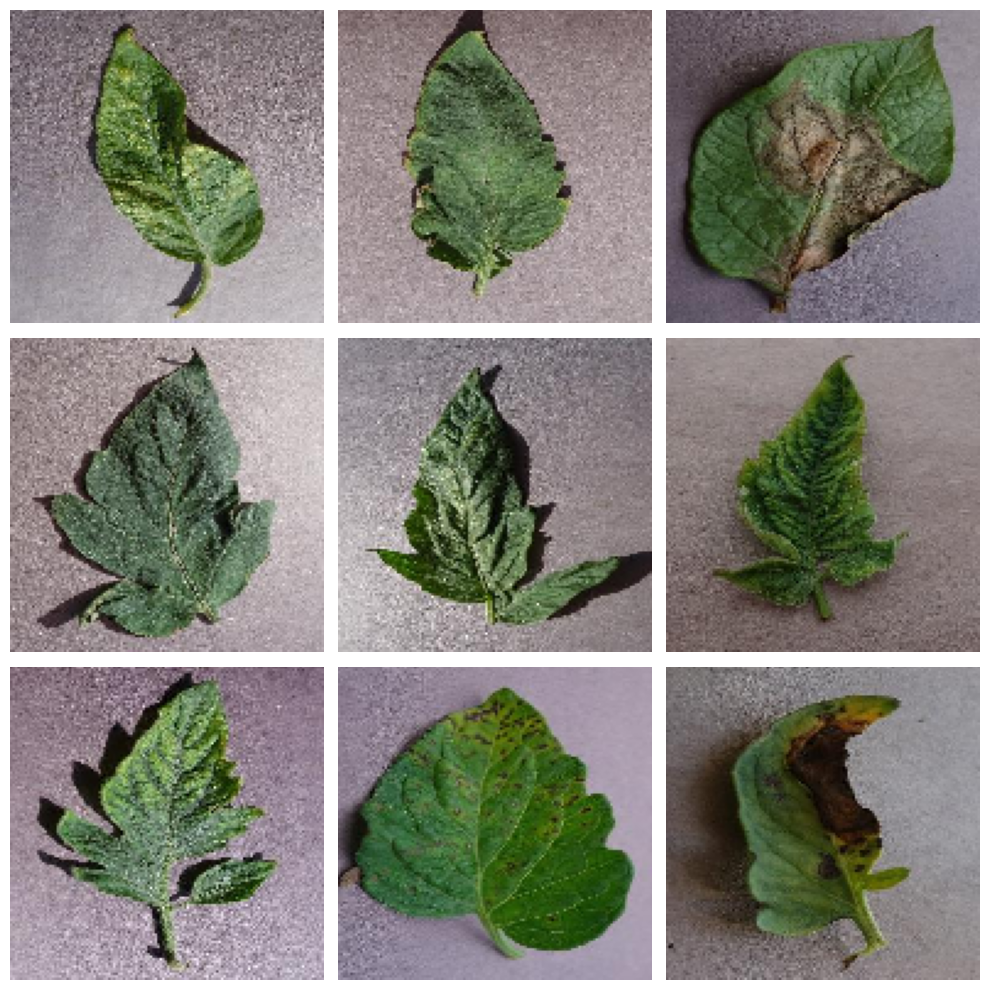

In [18]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(len(train_data.class_indices),
          activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         8,208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,947,024 (49.39 MB)

 Trainable params: 12,947,024 (49.39 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1259s 1s/step - accuracy: 0.5102 - loss: 1.3815 - val_accuracy: 0.1995 - val_loss: 2.1086
Epoch 2/5
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1252s 1s/step - accuracy: 0.5346 - loss: 1.0174 - val_accuracy: 0.2174 - val_loss: 2.1879
Epoch 3/5
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1253s 1s/step - accuracy: 0.5478 - loss: 0.9208 - val_accuracy: 0.1776 - val_loss: 3.1094
Epoch 4/5
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1242s 1s/step - accuracy: 0.5490 - loss: 0.8604 - val_accuracy: 0.1589 - val_loss: 3.6983
Epoch 5/5
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1241s 1s/step - accuracy: 0.5509 - loss: 0.8211 - val_accuracy: 0.2210 - val_loss: 3.9089


In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1246s 1s/step - accuracy: 0.5563 - loss: 0.7978 - val_accuracy: 0.1982 - val_loss: 3.7158
Epoch 2/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1226s 1s/step - accuracy: 0.5605 - loss: 0.7696 - val_accuracy: 0.1914 - val_loss: 5.3061
Epoch 3/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1225s 1s/step - accuracy: 0.5533 - loss: 0.7641 - val_accuracy: 0.1740 - val_loss: 4.8504
Epoch 4/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1281s 1s/step - accuracy: 0.5577 - loss: 0.7496 - val_accuracy: 0.1759 - val_loss: 5.4281
Epoch 5/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1261s 1s/step - accuracy: 0.5560 - loss: 0.7407 - val_accuracy: 0.1181 - val_loss: 5.4884
Epoch 6/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1227s 1s/step - accuracy: 0.5610 - loss: 0.7285 - val_accuracy: 0.1417 - val_loss: 6.0259
Epoch 7/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1226s 1s/step - accuracy: 0.5639 - loss: 0.7249 - val_accuracy: 0.1440 - val_loss: 6.2986
Epoch 8/10
1033/1033 ━━━━━━━━━━━━━━━━━━━━ 1224s 1s/step - accuracy: 0.5601 -

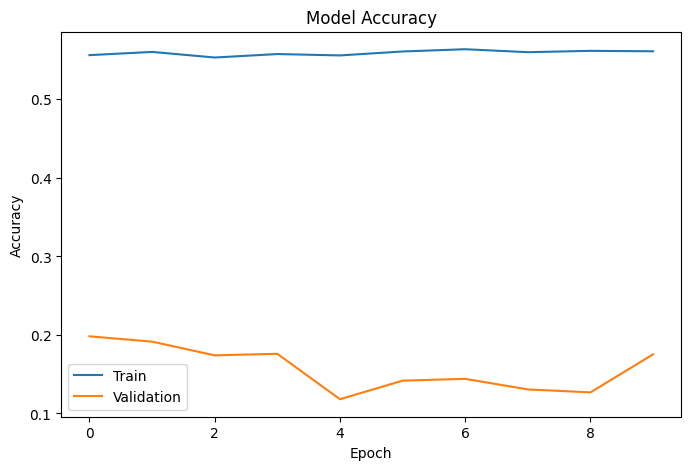

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

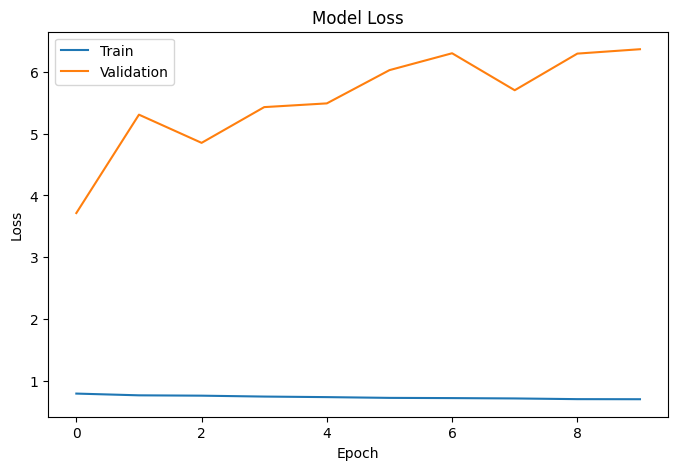

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [25]:
loss, accuracy = model.evaluate(val_data)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

258/258 ━━━━━━━━━━━━━━━━━━━━ 77s 299ms/step - accuracy: 0.1753 - loss: 6.3638
Validation Loss: 6.3638176918029785
Validation Accuracy: 0.17529398202896118


In [26]:
model.save("plant_disease_cnn.h5")
print("Model Saved Successfully!")

Model Saved Successfully!
